## Test (A-TWAIN .cnv data)

In [336]:
from kval.data import ctd
import importlib as imp
from kval.data.ship_ctd_tools import _ctd_visualize, _ctd_edit
from kval.file import xr_funcs
import xarray as xr
from kval.data import edit, dataset

%matplotlib widget

In [337]:
use_interactive = True

In [338]:
source_dir = '../../tests/test_data/sbe_files/sbe911plus/atwain_cruise_ctds/'

In [343]:

imp.reload(ctd)
imp.reload(_ctd_edit)

imp.reload(dataset)

<module 'kval.data.dataset' from '/home/oyvindl/work/code/python/kval/src/kval/data/dataset.py'>

In [348]:
    from kval import data

    # Load all .cnv files and join together into a single xarray Dataset:
    ds = data.ctd.ctds_from_cnv_dir(source_dir,
        station_from_filename=False,
        start_time_NMEA=False,
        processing_variable=True)

    # Manually removing points from the TEMP variable (from the TIME/STATION index 2):
    ds = edit.remove_points_profile(ds, "TEMP", 2, [193, 194, 195, 196, 197, 198, 199])

Found 3 .cnv files in  "../../tests/test_data/sbe_files/sbe911plus/atwain_cruise_ctds/".

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).
Loaded 3 profiles from list of Datasets.
NOTE: It seems the input data already binned -> using preexisting binning.


Joining profiles together:   0%|          | 0/3 [00:00<?, ?it/s]

KeyError: "No variable named 'TEMP'. Variables on the dataset include ['TEMP1', 'PTEMP1', 'CNDC1', 'PSAL1', 'SIGTH1', ..., 'LONGITUDE', 'PRES', 'TIME', 'CRUISE', 'PROCESSING']"

In [344]:
ds = ctd.ctds_from_cnv_dir(source_dir)
ds = ctd.metadata_auto(ds, NPI=True)

Found 3 .cnv files in  "../../tests/test_data/sbe_files/sbe911plus/atwain_cruise_ctds/".

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).
Loaded 3 profiles from list of Datasets.
NOTE: It seems the input data already binned -> using preexisting binning.


Joining profiles together:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

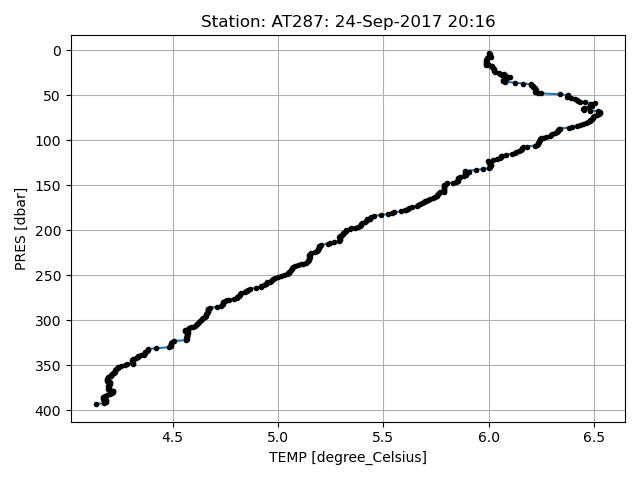

In [345]:
ds = ctd.hand_remove_points(ds, 'TEMP',2)

In [346]:
ds

<xarray.Dataset> Size: 93kB
Dimensions:            (TIME: 3, PRES: 527)
Coordinates:
  * PRES               (PRES) float64 4kB 3.0 4.0 5.0 6.0 ... 527.0 528.0 529.0
  * TIME               (TIME) float64 24B 1.743e+04 1.743e+04 1.743e+04
Data variables:
    TEMP               (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan nan
    PTEMP              (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan nan
    CNDC               (TIME, PRES) float64 13kB nan 34.68 34.69 ... nan nan nan
    PSAL               (TIME, PRES) float64 13kB nan 34.98 34.98 ... nan nan nan
    SIGTH              (TIME, PRES) float64 13kB nan 27.49 27.49 ... nan nan nan
    CHLA_fluorescence  (TIME, PRES) float64 13kB nan 1.39 1.293 ... nan nan nan
    SBE_FLAG           (TIME, PRES) float64 13kB nan 0.0 0.0 0.0 ... nan nan nan
    STATION            (TIME) <U5 60B 'AT285' 'AT286' 'AT287'
    LATITUDE           (TIME) float64 24B 80.11 80.07 80.04
    LONGITUDE          (TIME) float64 24B 9.875 10.38 10.75
    CRUISE             <U27 108B '!! CRUISE (Not assigned) !!'
    PROCESSING         object 8B None
Attributes: (12/42)
    history:                         2017-09-24 to 2017-09-24: Data collectio...
    source:                          CTD profiles from SBE911+
    instrument:                      In Situ/Laboratory Instruments>Profilers...
    platform:                        Water-based Platforms>Vessels
    institution:                     Norwegian Polar Institute (NPI)
    license:                         CC-BY 4.0
    ...                              ...
    standard_name_vocabulary:        CF Standard Name Table v83
    instrument_vocabulary:           NASA/GCMD Instrument Keywords Version 17.2
    keywords_vocabulary:             NASA/GCMD Science Keywords 9.1.5
    iso_topic_category:              oceans
    Conventions:                     ACDD-1.3, CF-1.8
    naming_authority:                npolar.no

In [347]:
    from kval import data

    # Load all .cnv files and join together into a single xarray Dataset:
    ds = data.ctd.ctds_from_cnv_dir(cnv_dir,
        station_from_filename=False,
        start_time_NMEA=False,
        processing_variable=True)

    # Manually removing points from the TEMP variable (from the TIME/STATION index 2):
    ds = edit.remove_points_profile(ds, "TEMP", 2, [193, 194, 195, 196, 197, 198, 199])

Exception: Did not find any .cnv files in the specified directory ("./"). Is there an error in the path?

In [311]:
remove_bool = np.array([False, False, False, False, False,False, 
                        True, True, True, False, False,False])

In [251]:
np.where(remove_bool)[0]

array([6, 7, 8])

In [242]:
import numpy as np

In [243]:
np.where?

Call signature:  np.where(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <built-in function where>
Docstring:      
where(condition, [x, y], /)

Return elements chosen from `x` or `y` depending on `condition`.

.. note::
    When only `condition` is provided, this function is a shorthand for
    ``np.asarray(condition).nonzero()``. Using `nonzero` directly should be
    preferred, as it behaves correctly for subclasses. The rest of this
    documentation covers only the case where all three arguments are
    provided.

Parameters
----------
condition : array_like, bool
    Where True, yield `x`, otherwise yield `y`.
x, y : array_like
    Values from which to choose. `x`, `y` and `condition` need to be
    broadcastable to some shape.

Returns
-------
out : ndarray
    An array with elements from `x` where `condition` is True, and elements
    from `y` elsewhere.

See Also
--------
choose
nonzero : The function that is called when x and y are omitted

Notes


In [198]:
ds

<xarray.Dataset> Size: 93kB
Dimensions:             (TIME: 3, PRES: 527)
Coordinates:
  * PRES                (PRES) float64 4kB 3.0 4.0 5.0 6.0 ... 527.0 528.0 529.0
  * TIME                (TIME) float64 24B 1.743e+04 1.743e+04 1.743e+04
Data variables:
    TEMP1               (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    PTEMP1              (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    CNDC1               (TIME, PRES) float64 13kB nan 34.68 34.69 ... nan nan
    PSAL1               (TIME, PRES) float64 13kB nan 34.98 34.98 ... nan nan
    SIGTH1              (TIME, PRES) float64 13kB nan 27.49 27.49 ... nan nan
    CHLA1_fluorescence  (TIME, PRES) float64 13kB nan 1.39 1.293 ... nan nan nan
    SBE_FLAG            (TIME, PRES) float64 13kB nan 0.0 0.0 ... nan nan nan
    STATION             (TIME) <U5 60B 'AT285' 'AT286' 'AT287'
    LATITUDE            (TIME) float64 24B 80.11 80.07 80.04
    LONGITUDE           (TIME) float64 24B 9.875 10.38 10.75
    CRUISE              <U27 108B '!! CRUISE (Not assigned) !!'
    PROCESSING          object 8B None
Attributes:
    binned:        1 decibars (SBE software)
    history:       2017-09-24 to 2017-09-24: Data collection.\n2018-07-23: Pr...
    source_files:  E.g. AT285.HEX, AT285.XMLCON -> AT285.CNV
    featureType:   profile

In [173]:
import glob2

In [174]:
cnv_list = glob2.glob(source_dir + '*.cnv')

In [175]:
ds = ctd.ctds_from_cnv_list(cnv_list)


NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).
Loaded 3 profiles from list of Datasets.
NOTE: It seems the input data already binned -> using preexisting binning.


Joining profiles together:   0%|          | 0/3 [00:00<?, ?it/s]

In [179]:
print(ds.PROCESSING.python_script)

from kval.data import ctd
cnv_list = [{files}] # A list of strings specifying paths to all files in *source_files*.

# Load all .cnv files into a single xarray Dataset:
ds = ctd.ctds_from_cnv_list(cnv_list,
    station_from_filename=False,
    start_time_NMEA=False,
    processing_variable=True)


In [180]:

# Load all .cnv files into a single xarray Dataset:
ds = ctd.ctds_from_cnv_list(cnv_list,
    station_from_filename=False,
    start_time_NMEA=False,
    processing_variable=True)


NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).

NOTE: Failed to extract sample time info (no timeS or timeJ in .cnv file).
(Not a big problem, the start_time can be used to assign a profile time).
Loaded 3 profiles from list of Datasets.
NOTE: It seems the input data already binned -> using preexisting binning.


Joining profiles together:   0%|          | 0/3 [00:00<?, ?it/s]

In [139]:
import os

In [6]:
cnv_list

NameError: name 'cnv_list' is not defined

In [213]:
ds = ctd.metadata_auto(ds, NPI=True)

In [214]:
ds

<xarray.Dataset> Size: 93kB
Dimensions:            (TIME: 3, PRES: 527)
Coordinates:
  * PRES               (PRES) float64 4kB 3.0 4.0 5.0 6.0 ... 527.0 528.0 529.0
  * TIME               (TIME) float64 24B 1.743e+04 1.743e+04 1.743e+04
Data variables:
    TEMP               (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan nan
    PTEMP              (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan nan
    CNDC               (TIME, PRES) float64 13kB nan 34.68 34.69 ... nan nan nan
    PSAL               (TIME, PRES) float64 13kB nan 34.98 34.98 ... nan nan nan
    SIGTH              (TIME, PRES) float64 13kB nan 27.49 27.49 ... nan nan nan
    CHLA_fluorescence  (TIME, PRES) float64 13kB nan 1.39 1.293 ... nan nan nan
    SBE_FLAG           (TIME, PRES) float64 13kB nan 0.0 0.0 0.0 ... nan nan nan
    STATION            (TIME) <U5 60B 'AT285' 'AT286' 'AT287'
    LATITUDE           (TIME) float64 24B 80.11 80.07 80.04
    LONGITUDE          (TIME) float64 24B 9.875 10.38 10.75
    CRUISE             <U27 108B '!! CRUISE (Not assigned) !!'
    PROCESSING         object 8B None
Attributes: (12/42)
    history:                         2017-09-24 to 2017-09-24: Data collectio...
    source:                          CTD profiles from SBE911+
    instrument:                      In Situ/Laboratory Instruments>Profilers...
    platform:                        Water-based Platforms>Vessels
    institution:                     Norwegian Polar Institute (NPI)
    license:                         CC-BY 4.0
    ...                              ...
    standard_name_vocabulary:        CF Standard Name Table v83
    instrument_vocabulary:           NASA/GCMD Instrument Keywords Version 17.2
    keywords_vocabulary:             NASA/GCMD Science Keywords 9.1.5
    iso_topic_category:              oceans
    Conventions:                     ACDD-1.3, CF-1.8
    naming_authority:                npolar.no

In [7]:
ctd.metadata_to_txt(ds, 'test')

In [8]:
ctd.check_file_with_button(ds)

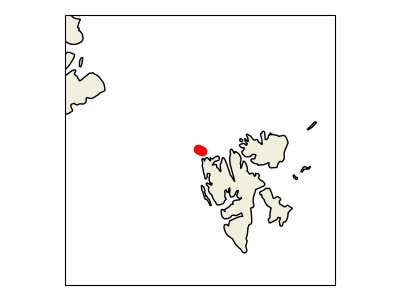

In [8]:
if use_interactive:
    ctd.map(ds)

In [9]:
if use_interactive:
    ctd.contour(ds)

In [10]:
if use_interactive:
    ctd.inspect_profiles(ds)

In [11]:
if use_interactive:
    ctd.inspect_dual_sensors(ds)

Cannot inspect dual sensors bacause we no dual sensors were found in the dataset..


In [12]:
ctd.to_netcdf(ds, '.')

Updated history attribute. Current content:
---
2017-09-24 to 2017-09-24: Data collection.
2018-07-23: Processed to .cnv using SBE software (details in "SBE_processing").
2024-08-09: Post-processing.
2024-08-09: Creation of this netcdf file.
---
Exported netCDF file as: DATASET_NO_NAME.nc


In [13]:
imp.reload(edit)


imp.reload(dataset)

<module 'kval.data.dataset' from '/home/oyvindl/work/code/python/kval/src/kval/data/dataset.py'>

In [14]:
ds0 = ds.copy()

In [15]:
ctd.inspect_profiles(ds)

In [16]:
ds

<xarray.Dataset> Size: 93kB
Dimensions:             (TIME: 3, PRES: 527)
Coordinates:
  * PRES                (PRES) float64 4kB 3.0 4.0 5.0 6.0 ... 527.0 528.0 529.0
  * TIME                (TIME) float64 24B 1.743e+04 1.743e+04 1.743e+04
Data variables:
    TEMP                (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    PTEMP               (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    CNDC                (TIME, PRES) float64 13kB nan 34.68 34.69 ... nan nan
    PSAL                (TIME, PRES) float64 13kB nan 34.98 34.98 ... nan nan
    SIGTH               (TIME, PRES) float64 13kB nan 27.49 27.49 ... nan nan
    CHLA_fluorescence   (TIME, PRES) float64 13kB nan 1.39 1.293 ... nan nan nan
    SBE_FLAG            (TIME, PRES) float64 13kB nan 0.0 0.0 ... nan nan nan
    STATION             (TIME) <U5 60B 'AT285' 'AT286' 'AT287'
    LATITUDE            (TIME) float64 24B 80.11 80.07 80.04
    LONGITUDE           (TIME) float64 24B 9.875 10.38 10.75
    CRUISE              <U27 108B '!! CRUISE (Not assigned) !!'
    PROCESSING_HISTORY  object 8B None
Attributes: (12/44)
    history:                         2017-09-24 to 2017-09-24: Data collectio...
    date_created:                    2024-08-09T15:46:08Z
    source:                          CTD profiles from SBE911+
    instrument:                      In Situ/Laboratory Instruments>Profilers...
    platform:                        Water-based Platforms>Vessels
    institution:                     Norwegian Polar Institute (NPI)
    ...                              ...
    standard_name_vocabulary:        CF Standard Name Table v83
    instrument_vocabulary:           NASA/GCMD Instrument Keywords Version 17.2
    keywords_vocabulary:             NASA/GCMD Science Keywords 9.1.5
    iso_topic_category:              oceans
    Conventions:                     ACDD-1.3, CF-1.8
    naming_authority:                npolar.no

In [17]:
imp.reload(edit)
TIME_index = 2
varnm = 'TEMP'
ds2 = edit.remove_points_profile(ds0.copy(), varnm, TIME_index, [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,])

In [18]:
import matplotlib.pyplot as plt 
plt.close('all')

In [19]:
ctd.inspect_profiles(ds2)

In [20]:
imp.reload(dataset)


<module 'kval.data.dataset' from '/home/oyvindl/work/code/python/kval/src/kval/data/dataset.py'>

In [22]:
ds

<xarray.Dataset> Size: 93kB
Dimensions:             (TIME: 3, PRES: 527)
Coordinates:
  * PRES                (PRES) float64 4kB 3.0 4.0 5.0 6.0 ... 527.0 528.0 529.0
  * TIME                (TIME) float64 24B 1.743e+04 1.743e+04 1.743e+04
Data variables: (12/13)
    TEMP                (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    PTEMP               (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    CNDC                (TIME, PRES) float64 13kB nan 34.68 34.69 ... nan nan
    PSAL                (TIME, PRES) float64 13kB nan 34.98 34.98 ... nan nan
    SIGTH               (TIME, PRES) float64 13kB nan 27.49 27.49 ... nan nan
    CHLA_fluorescence   (TIME, PRES) float64 13kB nan 1.39 1.293 ... nan nan nan
    ...                  ...
    STATION             (TIME) <U5 60B 'AT285' 'AT286' 'AT287'
    LATITUDE            (TIME) float64 24B 80.11 80.07 80.04
    LONGITUDE           (TIME) float64 24B 9.875 10.38 10.75
    CRUISE              <U27 108B '!! CRUISE (Not assigned) !!'
    PROCESSING_HISTORY  object 8B None
    PROCESSING          object 8B None
Attributes: (12/44)
    history:                         2017-09-24 to 2017-09-24: Data collectio...
    date_created:                    2024-08-09T15:46:08Z
    source:                          CTD profiles from SBE911+
    instrument:                      In Situ/Laboratory Instruments>Profilers...
    platform:                        Water-based Platforms>Vessels
    institution:                     Norwegian Polar Institute (NPI)
    ...                              ...
    standard_name_vocabulary:        CF Standard Name Table v83
    instrument_vocabulary:           NASA/GCMD Instrument Keywords Version 17.2
    keywords_vocabulary:             NASA/GCMD Science Keywords 9.1.5
    iso_topic_category:              oceans
    Conventions:                     ACDD-1.3, CF-1.8
    naming_authority:                npolar.no

In [128]:
ds = ds0.copy()

In [131]:
ds = dataset.add_processing_history_var(ds)

In [132]:
ds

<xarray.Dataset> Size: 106kB
Dimensions:             (TIME: 3, PRES: 527)
Coordinates:
  * PRES                (PRES) float64 4kB 3.0 4.0 5.0 6.0 ... 527.0 528.0 529.0
  * TIME                (TIME) float64 24B 1.743e+04 1.743e+04 1.743e+04
Data variables: (12/13)
    TEMP                (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    PTEMP               (TIME, PRES) float64 13kB nan 6.362 6.367 ... nan nan
    CNDC                (TIME, PRES) float64 13kB nan 34.68 34.69 ... nan nan
    PSAL                (TIME, PRES) float64 13kB nan 34.98 34.98 ... nan nan
    SIGTH               (TIME, PRES) float64 13kB nan 27.49 27.49 ... nan nan
    CHLA_fluorescence   (TIME, PRES) float64 13kB nan 1.39 1.293 ... nan nan nan
    ...                  ...
    STATION             (TIME) <U5 60B 'AT285' 'AT286' 'AT287'
    LATITUDE            (TIME) float64 24B 80.11 80.07 80.04
    LONGITUDE           (TIME) float64 24B 9.875 10.38 10.75
    CRUISE              <U27 108B '!! CRUISE (Not assigned) !!'
    CHLA                (TIME, PRES) float64 13kB nan 1.829 1.722 ... nan nan
    PROCESSING_HISTORY  object 8B None
Attributes: (12/44)
    history:                         2017-09-24 to 2017-09-24: Data collectio...
    date_created:                    2024-08-09T15:12:06Z
    source:                          CTD profiles from SBE911+
    instrument:                      In Situ/Laboratory Instruments>Profilers...
    platform:                        Water-based Platforms>Vessels
    institution:                     Norwegian Polar Institute (NPI)
    ...                              ...
    standard_name_vocabulary:        CF Standard Name Table v83
    instrument_vocabulary:           NASA/GCMD Instrument Keywords Version 17.2
    keywords_vocabulary:             NASA/GCMD Science Keywords 9.1.5
    iso_topic_category:              oceans
    Conventions:                     ACDD-1.3, CF-1.8
    naming_authority:                npolar.no